In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,MinMaxScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [3]:
df = pd.read_csv("market_data.csv")
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [5]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [8]:
df.corr(numeric_only=True)

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
Item_Weight,1.000000,-0.014048,0.027141,-0.011588,0.014123
Item_Visibility,-0.014048,1.000000,-0.001315,-0.074834,-0.128625
Item_MRP,0.027141,-0.001315,1.000000,0.005020,0.567574
Outlet_Establishment_Year,-0.011588,-0.074834,0.005020,1.000000,-0.049135
Item_Outlet_Sales,0.014123,-0.128625,0.567574,-0.049135,1.000000


In [16]:
df.isna().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [10]:
df.shape

(8523, 12)

In [ ]:
cols = ['Item_Weight','Outlet_Size']

df['Item_Weight'].fillna(df['Item_Weight'].mean(),inplace=True)
df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0],inplace=True)

C:\Users\sujay\AppData\Local\Temp\ipykernel_19600\1439584920.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].fillna(df['Item_Weight'].mean(),inplace=True)


In [15]:
df['Outlet_Size'].unique()

array(['Medium', 'High', 'Small'], dtype=object)

In [17]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [33]:
cols = df.select_dtypes(include=["number"]).columns
print(cols)
# plt.boxplot(df['Item_MRP'])

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales'],
      dtype='object')


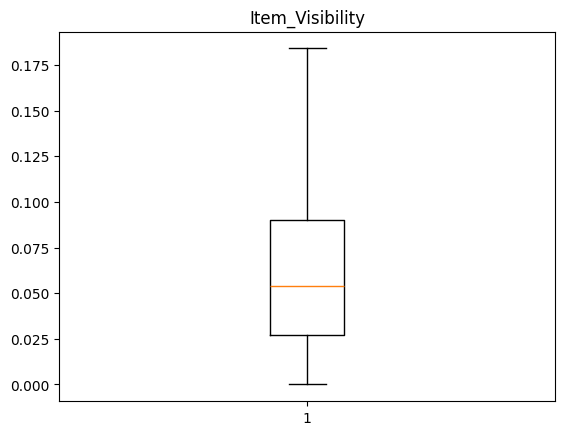

In [67]:
i = 'Item_Visibility'
plt.boxplot(df[i])
plt.title(i)
plt.show()


In [66]:
col = 'Item_Visibility'
q1 = df['Item_Visibility'].quantile(0.25)
q3 = df['Item_Visibility'].quantile(0.75)
IQR = q3-q1

ub = q3+(1.5*IQR)
lb = q1-(1.5*IQR)
mean = df['Item_Visibility'].mean()

df['Item_Visibility'] = np.where((df['Item_Visibility']<ub)&(df['Item_Visibility']>lb),df['Item_Visibility'],mean)


In [70]:
cols = df.select_dtypes(include="object").columns
cols

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

In [75]:
le=LabelEncoder()
for i in cols:
    df[i] = le.fit_transform(df[i])
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,156,9.300,1,0.016047,4,249.8092,9,1999,1,0,1,3735.1380
1,8,5.920,2,0.019278,14,48.2692,3,2009,1,2,2,443.4228
2,662,17.500,1,0.016760,10,141.6180,9,1999,1,0,1,2097.2700
3,1121,19.200,2,0.000000,6,182.0950,0,1998,1,2,0,732.3800
4,1297,8.930,1,0.000000,9,53.8614,1,1987,0,2,1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,370,6.865,1,0.056783,13,214.5218,1,1987,0,2,1,2778.3834
8519,897,8.380,2,0.046982,0,108.1570,7,2002,1,1,1,549.2850
8520,1357,10.600,1,0.035186,8,85.1224,6,2004,2,1,1,1193.1136
8521,681,7.210,2,0.145221,13,103.1332,3,2009,1,2,2,1845.5976


In [78]:
ss = StandardScaler()
df.iloc[:,:-1] = ss.fit_transform(df.iloc[:,:-1])
df

C:\Users\sujay\AppData\Local\Temp\ipykernel_19600\1463081071.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.38851383 -1.71799137 -0.26205684 ...  1.28515188 -0.21975905
 -1.62449099]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.iloc[:,:-1] = ss.fit_transform(df.iloc[:,:-1])
C:\Users\sujay\AppData\Local\Temp\ipykernel_19600\1463081071.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.57284357  0.97809218 -0.57284357 ... -0.57284357  0.97809218
 -0.57284357]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.iloc[:,:-1] = ss.fit_transform(df.iloc[:,:-1])
C:\Users\sujay\AppData\Local\Temp\ipykernel_19600\1463081071.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.766

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,-1.388514,-0.841872,-0.572844,-1.037016,-0.766479,1.747454,1.507813,0.139541,-0.284581,-1.369334,-0.252658,3735.1380
1,-1.717991,-1.641706,0.978092,-0.964561,1.608963,-1.489023,-0.607071,1.334103,-0.284581,1.091569,1.002972,443.4228
2,-0.262057,1.098554,-0.572844,-1.021032,0.658786,0.010040,1.507813,0.139541,-0.284581,-1.369334,-0.252658,2097.2700
3,0.759769,1.500838,0.978092,-1.396885,-0.291391,0.660050,-1.664513,0.020085,-0.284581,1.091569,-1.508289,732.3800
4,1.151580,-0.929428,-0.572844,-1.396885,0.421242,-1.399220,-1.312032,-1.293934,-1.950437,1.091569,-0.252658,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,-0.912107,-1.418084,-0.572844,-0.123489,1.371418,1.180783,-1.312032,-1.293934,-1.950437,1.091569,-0.252658,2778.3834
8519,0.261100,-1.059578,0.978092,-0.343280,-1.716656,-0.527301,0.802852,0.497909,-0.284581,-0.138882,-0.252658,549.2850
8520,1.285152,-0.534243,-0.572844,-0.607815,0.183698,-0.897208,0.450371,0.736822,1.381274,-0.138882,-0.252658,1193.1136
8521,-0.219759,-1.336444,0.978092,1.859762,1.371418,-0.607977,-0.607071,1.334103,-0.284581,1.091569,1.002972,1845.5976


In [79]:
X = df[['Outlet_Identifier', 'Outlet_Type']]

# Select target
y = df['Item_Outlet_Sales']

# Split data
X_Train, X_Test, Y_Train, Y_Test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [80]:
lr = LinearRegression()
lr.fit(X_Train,Y_Train)
y_pred = lr.predict(X_Test)


In [81]:
y_pred

array([1753.93779805, 2278.09930229, 2352.97951718, ..., 1753.93779805,
       2729.72249604, 2203.2190874 ], shape=(1705,))

In [82]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R2 Score:", r2_score(Y_Test, y_pred))
print("MAE:", mean_absolute_error(Y_Test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(Y_Test, y_pred)))


R2 Score: 0.19038028647618366
MAE: 1162.64898464573
RMSE: 1483.4157025933555
